In [3]:
import os

base_path = r"C:\Users\Cyber\Desktop\New folder"

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith((".keras", ".h5", ".hdf5")):
            print(os.path.join(root, file))
            

C:\Users\Cyber\Desktop\New folder\trained_DNN _model\DNN_AEEEM_Risk_Model.keras


In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os

model_path = r"C:\Users\Cyber\Desktop\New folder\trained_DNN _model\DNN_AEEEM_Risk_Model.keras"

# Check whether file exists
print("File exists:", os.path.exists(model_path))

# Load model
model = tf.keras.models.load_model(model_path)

print("Model loaded successfully!")
print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)


File exists: True
Model loaded successfully!
Input shape : (None, 56)
Output shape: (None, 1)


In [6]:
print(model.summary())


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,413 (693.02 KB)

 Trainable params: 58,817 (229.75 KB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 117,636 (459.52 KB)

None


In [7]:
sample = np.zeros((1, 56), dtype=np.float32)

prediction = model.predict(sample, verbose=0)

print("Raw prediction:", prediction)
print("Prediction value:", float(prediction[0][0]))

Raw prediction: [[0.9993491]]
Prediction value: 0.9993491172790527


In [9]:
print("Model expects:", model.input_shape[-1])
print("Sample has:", sample.shape[1])

Model expects: 56
Sample has: 4


In [11]:
# ============================================================
# AEEEM DNN MODEL - ONE CELL TESTING
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. MODEL PATH
# ------------------------------------------------------------

model_path = r"C:\Users\Cyber\Desktop\New folder\trained_DNN _model\DNN_AEEEM_Risk_Model.keras"

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found:\n{model_path}")

model = tf.keras.models.load_model(model_path)

print("=" * 70)
print("MODEL LOADED SUCCESSFULLY")
print("=" * 70)

print("Model input shape :", model.input_shape)
print("Model output shape:", model.output_shape)


# ------------------------------------------------------------
# 2. FIND ALL CSV FILES
# ------------------------------------------------------------

base_path = r"C:\Users\Cyber\Desktop\New folder"

csv_files = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("\n" + "=" * 70)
print("CSV FILES FOUND")
print("=" * 70)

if not csv_files:
    raise FileNotFoundError(
        "No CSV files were found inside:\n" + base_path
    )

for i, path in enumerate(csv_files):
    try:
        temp = pd.read_csv(path)
        print(
            f"[{i}] {path}\n"
            f"    Shape: {temp.shape}\n"
            f"    Columns: {len(temp.columns)}"
        )
    except Exception as e:
        print(f"[{i}] Could not read: {path}")
        print("    Error:", e)


# ------------------------------------------------------------
# 3. SHOW DATASET DETAILS
# ------------------------------------------------------------

# IMPORTANT:
# Change this number if the correct CSV is not index 0.
DATASET_INDEX = 0

if DATASET_INDEX >= len(csv_files):
    raise IndexError("DATASET_INDEX is outside the available CSV files.")

data_path = csv_files[DATASET_INDEX]

df = pd.read_csv(data_path)

print("\n" + "=" * 70)
print("SELECTED DATASET")
print("=" * 70)

print("File:", data_path)
print("Shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns):
    print(i, ":", col)


# ------------------------------------------------------------
# 4. CHECK FOR 56 FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FEATURE CHECK")
print("=" * 70)

expected_features = model.input_shape[-1]

print("Model expects:", expected_features, "features")

print("Dataset columns:", len(df.columns))

if len(df.columns) == expected_features:
    print("Dataset has exactly 56 columns.")

elif len(df.columns) == expected_features + 1:
    print(
        "Dataset has 57 columns. "
        "One column may be the target."
    )

else:
    print(
        f"WARNING: Dataset has {len(df.columns)} columns, "
        f"but model expects {expected_features} features."
    )


# ------------------------------------------------------------
# 5. DISPLAY FIRST ROWS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)

display(df.head())


# ------------------------------------------------------------
# 6. TRY TO IDENTIFY TARGET COLUMN
# ------------------------------------------------------------

possible_targets = [
    "risk",
    "Risk",
    "target",
    "Target",
    "label",
    "Label",
    "class",
    "Class",
    "risk_level",
    "Risk_Level"
]

target_column = None

for col in possible_targets:
    if col in df.columns:
        target_column = col
        break

print("\n" + "=" * 70)
print("TARGET CHECK")
print("=" * 70)

if target_column:
    print("Possible target column found:", target_column)
else:
    print("No standard target-column name was automatically found.")


# ------------------------------------------------------------
# 7. PREPARE FEATURES
# ------------------------------------------------------------

if target_column:

    X = df.drop(columns=[target_column])
    y = df[target_column]

    print("\nX shape:", X.shape)
    print("y shape:", y.shape)

else:

    X = df.copy()
    y = None

    print("\nNo target removed.")
    print("X shape:", X.shape)


# ------------------------------------------------------------
# 8. CHECK NUMBER OF FEATURES
# ------------------------------------------------------------

if X.shape[1] != expected_features:

    print("\n" + "=" * 70)
    print("CANNOT RUN PREDICTION YET")
    print("=" * 70)

    print(
        f"The model requires {expected_features} features, "
        f"but X currently contains {X.shape[1]}."
    )

    print(
        "\nYou must use the SAME 56 features and the SAME "
        "preprocessing that were used during model training."
    )

else:

    # --------------------------------------------------------
    # 9. CONVERT FEATURES TO NUMPY
    # --------------------------------------------------------

    X = X.astype(np.float32)

    print("\nFeature shape is correct:", X.shape)


    # --------------------------------------------------------
    # 10. PREDICT
    # --------------------------------------------------------

    prediction = model.predict(X, verbose=0)

    probabilities = prediction.ravel()

    print("\n" + "=" * 70)
    print("PREDICTIONS")
    print("=" * 70)

    print("Prediction shape:", prediction.shape)

    print("\nFirst 10 probabilities:")

    for i, p in enumerate(probabilities[:10]):
        print(f"Sample {i + 1}: {p:.6f}")


    # --------------------------------------------------------
    # 11. BINARY CLASSIFICATION
    # --------------------------------------------------------

    y_pred = (probabilities >= 0.5).astype(int)

    print("\nFirst 10 predicted classes:")
    print(y_pred[:10])


    # --------------------------------------------------------
    # 12. RESULTS TABLE
    # --------------------------------------------------------

    results = pd.DataFrame({
        "Prediction_Probability": probabilities,
        "Predicted_Class": y_pred
    })

    if y is not None:
        results["Actual_Class"] = y.values

    print("\n" + "=" * 70)
    print("RESULTS")
    print("=" * 70)

    display(results.head(20))


    # --------------------------------------------------------
    # 13. EVALUATION IF TARGET EXISTS
    # --------------------------------------------------------

    if y is not None:

        # Try to convert common string labels to 0/1
        if not pd.api.types.is_numeric_dtype(y):

            unique_labels = list(y.dropna().unique())

            print("\nActual labels found:")
            print(unique_labels)

            if len(unique_labels) == 2:

                label_mapping = {
                    unique_labels[0]: 0,
                    unique_labels[1]: 1
                }

                y_numeric = y.map(label_mapping).astype(int)

            else:

                print(
                    "\nMore than two classes detected. "
                    "This model has one output, so verify your label encoding."
                )

                y_numeric = None

        else:

            y_numeric = y.astype(int)


        if y_numeric is not None:

            accuracy = accuracy_score(
                y_numeric,
                y_pred
            )

            print("\n" + "=" * 70)
            print("MODEL PERFORMANCE")
            print("=" * 70)

            print(
                f"Test Accuracy: {accuracy * 100:.2f}%"
            )

            print("\nClassification Report:")

            print(
                classification_report(
                    y_numeric,
                    y_pred,
                    zero_division=0
                )
            )

            print("\nConfusion Matrix:")

            print(
                confusion_matrix(
                    y_numeric,
                    y_pred
                )
            )


    # --------------------------------------------------------
    # 14. SAVE RESULTS
    # --------------------------------------------------------

    output_file = os.path.join(
        base_path,
        "DNN_AEEEM_Test_Predictions.csv"
    )

    results.to_csv(
        output_file,
        index=False
    )

    print("\n" + "=" * 70)
    print("DONE")
    print("=" * 70)

    print(
        "Prediction results saved to:"
    )

    print(output_file)

MODEL LOADED SUCCESSFULLY
Model input shape : (None, 56)
Model output shape: (None, 1)

CSV FILES FOUND
[0] C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\numpy\random\tests\data\mt19937-testset-1.csv
    Shape: (1000, 2)
    Columns: 2
[1] C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\numpy\random\tests\data\mt19937-testset-2.csv
    Shape: (1000, 2)
    Columns: 2
[2] C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\numpy\random\tests\data\pcg64-testset-1.csv
    Shape: (1000, 2)
    Columns: 2
[3] C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\numpy\random\tests\data\pcg64-testset-2.csv
    Shape: (1000, 2)
    Columns: 2
[4] C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\numpy\random\tests\data\pcg64dxsm-testset-1.csv
    Shape: (1000, 2)
    Columns: 2
[5] C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\numpy\random\tests\data\pcg64dxsm-testset-2.csv
    Shape: (1000, 2)
    Columns: 2
[6] C:\Users\Cyber\Desktop\New f

,seed,0xdeadbeaf
0,0,0xc816921f
1,1,0xb3623c6d
2,2,0x5fa391bb
3,3,0x40178d9
4,4,0x7dcc9811



TARGET CHECK
No standard target-column name was automatically found.

No target removed.
X shape: (1000, 2)

CANNOT RUN PREDICTION YET
The model requires 56 features, but X currently contains 2.

You must use the SAME 56 features and the SAME preprocessing that were used during model training.


In [13]:
import os
import pandas as pd

# ============================================================
# FIND YOUR ACTUAL AEEEM / PROMISE DATASET
# ============================================================

base_path = r"C:\Users\Cyber\Desktop\New folder"

print("=" * 70)
print("SEARCHING FOR CSV FILES IN YOUR PROJECT")
print("=" * 70)

found = []

for root, dirs, files in os.walk(base_path):

    # Ignore Python environments and package folders
    dirs[:] = [
        d for d in dirs
        if d not in [".venv", "venv", "env", "__pycache__", "site-packages"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            path = os.path.join(root, file)

            try:
                df_temp = pd.read_csv(path)

                found.append((path, df_temp.shape))

                print("\nFile:", path)
                print("Shape:", df_temp.shape)
                print("Columns:", len(df_temp.columns))

                # Show columns only for reasonably large datasets
                if len(df_temp.columns) >= 20:
                    print("First columns:")
                    print(df_temp.columns.tolist()[:20])

            except Exception as e:
                pass


print("\n" + "=" * 70)
print("SEARCH COMPLETE")
print("=" * 70)

print("Number of project CSV files found:", len(found))


SEARCHING FOR CSV FILES IN YOUR PROJECT

File: C:\Users\Cyber\Desktop\New folder\dataset\AEEEM_combined.csv
Shape: (5371, 62)
Columns: 62
First columns:
['ck_oo_numberOfPrivateMethods', 'LDHH_lcom', 'LDHH_fanIn', 'numberOfNonTrivialBugsFoundUntil:', 'WCHU_numberOfPublicAttributes', 'WCHU_numberOfAttributes', 'CvsWEntropy', 'LDHH_numberOfPublicMethods', 'WCHU_fanIn', 'LDHH_numberOfPrivateAttributes', 'CvsEntropy', 'LDHH_numberOfPublicAttributes', 'WCHU_numberOfPrivateMethods', 'WCHU_numberOfMethods', 'ck_oo_numberOfPublicAttributes', 'ck_oo_noc', 'numberOfCriticalBugsFoundUntil:', 'ck_oo_wmc', 'LDHH_numberOfPrivateMethods', 'WCHU_numberOfPrivateAttributes']

SEARCH COMPLETE
Number of project CSV files found: 1


In [14]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD AEEEM DATASET
# ============================================================

data_path = r"C:\Users\Cyber\Desktop\New folder\dataset\AEEEM_combined.csv"

df = pd.read_csv(data_path)

print("=" * 70)
print("AEEEM DATASET")
print("=" * 70)

print("Shape:", df.shape)
print("Number of columns:", len(df.columns))

# ------------------------------------------------------------
# SHOW ALL COLUMNS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ALL 62 COLUMNS")
print("=" * 70)

for i, col in enumerate(df.columns):
    print(f"{i:2d}: {col}")

# ------------------------------------------------------------
# DATA TYPES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(df.dtypes)

# ------------------------------------------------------------
# MISSING VALUES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = df.isnull().sum()

print(
    missing[missing > 0].sort_values(ascending=False)
)

# ------------------------------------------------------------
# UNIQUE VALUES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("UNIQUE VALUES")
print("=" * 70)

for col in df.columns:
    unique_count = df[col].nunique()

    if unique_count <= 10:
        print(
            f"{col}: {unique_count} unique values -> "
            f"{df[col].dropna().unique()}"
        )

# ------------------------------------------------------------
# FIRST 5 ROWS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)

display(df.head())

# ------------------------------------------------------------
# NUMERIC COLUMNS
# ------------------------------------------------------------

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("\n" + "=" * 70)
print("NUMERIC FEATURES")
print("=" * 70)

print("Number of numeric columns:", len(numeric_columns))

for i, col in enumerate(numeric_columns):
    print(f"{i:2d}: {col}")
    

AEEEM DATASET
Shape: (5371, 62)
Number of columns: 62

ALL 62 COLUMNS
 0: ck_oo_numberOfPrivateMethods
 1: LDHH_lcom
 2: LDHH_fanIn
 3: numberOfNonTrivialBugsFoundUntil:
 4: WCHU_numberOfPublicAttributes
 5: WCHU_numberOfAttributes
 6: CvsWEntropy
 7: LDHH_numberOfPublicMethods
 8: WCHU_fanIn
 9: LDHH_numberOfPrivateAttributes
10: CvsEntropy
11: LDHH_numberOfPublicAttributes
12: WCHU_numberOfPrivateMethods
13: WCHU_numberOfMethods
14: ck_oo_numberOfPublicAttributes
15: ck_oo_noc
16: numberOfCriticalBugsFoundUntil:
17: ck_oo_wmc
18: LDHH_numberOfPrivateMethods
19: WCHU_numberOfPrivateAttributes
20: CvsLogEntropy
21: WCHU_noc
22: LDHH_numberOfAttributesInherited
23: WCHU_wmc
24: ck_oo_fanOut
25: ck_oo_numberOfLinesOfCode
26: ck_oo_numberOfAttributesInherited
27: ck_oo_numberOfMethods
28: ck_oo_dit
29: ck_oo_fanIn
30: LDHH_noc
31: WCHU_dit
32: ck_oo_lcom
33: WCHU_numberOfAttributesInherited
34: ck_oo_rfc
35: LDHH_wmc
36: LDHH_numberOfAttributes
37: LDHH_numberOfLinesOfCode
38: WCHU_fanOut

,ck_oo_numberOfPrivateMethods,LDHH_lcom,LDHH_fanIn,numberOfNonTrivialBugsFoundUntil:,WCHU_numberOfPublicAttributes,WCHU_numberOfAttributes,CvsWEntropy,LDHH_numberOfPublicMethods,WCHU_fanIn,LDHH_numberOfPrivateAttributes,...,LDHH_fanOut,LDHH_numberOfMethodsInherited,LDHH_rfc,ck_oo_numberOfMethodsInherited,ck_oo_numberOfPublicMethods,LDHH_cbo,WCHU_numberOfLinesOfCode,CvsExpEntropy,LDHH_numberOfMethods,class
0,3,0.002547,0.002555,4,0.00,3.04,0.393707,0.003049,1.01,0.004091,...,0.005627,0.000000,0.004406,8,8,0.008431,3.50,0.103594,0.003611,NaN
1,37,0.008643,0.004756,71,0.00,14.37,2.093750,0.001481,2.02,0.015332,...,0.018761,0.001486,0.060301,7,7,0.021602,43.12,0.328692,0.009906,NaN
2,3,0.001479,0.009143,5,1.01,3.08,0.484675,0.000000,6.17,0.001953,...,0.003117,0.001486,0.002325,7,2,0.011859,4.68,0.125841,0.001655,NaN
3,10,0.005642,0.005395,38,0.00,1.06,0.811584,0.000876,6.07,0.000739,...,0.020376,0.002338,0.030608,17,10,0.020478,24.06,0.170416,0.007000,NaN
4,1,0.001350,0.000000,1,1.01,1.01,0.031940,0.000876,0.00,0.000000,...,0.000566,0.003017,0.001492,22,7,0.000652,2.13,0.055912,0.001572,NaN



NUMERIC FEATURES
Number of numeric columns: 62
 0: ck_oo_numberOfPrivateMethods
 1: LDHH_lcom
 2: LDHH_fanIn
 3: numberOfNonTrivialBugsFoundUntil:
 4: WCHU_numberOfPublicAttributes
 5: WCHU_numberOfAttributes
 6: CvsWEntropy
 7: LDHH_numberOfPublicMethods
 8: WCHU_fanIn
 9: LDHH_numberOfPrivateAttributes
10: CvsEntropy
11: LDHH_numberOfPublicAttributes
12: WCHU_numberOfPrivateMethods
13: WCHU_numberOfMethods
14: ck_oo_numberOfPublicAttributes
15: ck_oo_noc
16: numberOfCriticalBugsFoundUntil:
17: ck_oo_wmc
18: LDHH_numberOfPrivateMethods
19: WCHU_numberOfPrivateAttributes
20: CvsLogEntropy
21: WCHU_noc
22: LDHH_numberOfAttributesInherited
23: WCHU_wmc
24: ck_oo_fanOut
25: ck_oo_numberOfLinesOfCode
26: ck_oo_numberOfAttributesInherited
27: ck_oo_numberOfMethods
28: ck_oo_dit
29: ck_oo_fanIn
30: LDHH_noc
31: WCHU_dit
32: ck_oo_lcom
33: WCHU_numberOfAttributesInherited
34: ck_oo_rfc
35: LDHH_wmc
36: LDHH_numberOfAttributes
37: LDHH_numberOfLinesOfCode
38: WCHU_fanOut
39: WCHU_lcom
40: ck_

In [15]:
# ============================================================
# INSPECT TRAINED DNN MODEL
# ============================================================

import tensorflow as tf

model_path = r"C:\Users\Cyber\Desktop\New folder\trained_DNN _model\DNN_AEEEM_Risk_Model.keras"

model = tf.keras.models.load_model(model_path)

print("=" * 70)
print("MODEL INFORMATION")
print("=" * 70)

print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)

print("\n" + "=" * 70)
print("MODEL LAYERS")
print("=" * 70)

for i, layer in enumerate(model.layers):

    print(
        f"{i}: "
        f"{layer.name} | "
        f"{layer.__class__.__name__} | "
        f"Input: {layer.input_shape if hasattr(layer, 'input_shape') else 'N/A'} | "
        f"Output: {layer.output_shape if hasattr(layer, 'output_shape') else 'N/A'}"
    )

print("\n" + "=" * 70)
print("MODEL SUMMARY")
print("=" * 70)

model.summary()

# ------------------------------------------------------------
# CHECK FOR NORMALIZATION / SCALING LAYERS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("POSSIBLE PREPROCESSING LAYERS")
print("=" * 70)

for layer in model.layers:

    name = layer.__class__.__name__.lower()

    if any(x in name for x in [
        "normalization",
        "rescaling",
        "preprocessing"
    ]):

        print("Preprocessing layer found:")
        print(layer)

MODEL INFORMATION
Input shape : (None, 56)
Output shape: (None, 1)

MODEL LAYERS
0: dense_10 | Dense | Input: N/A | Output: N/A
1: batch_normalization_8 | BatchNormalization | Input: N/A | Output: N/A
2: dropout_8 | Dropout | Input: N/A | Output: N/A
3: dense_11 | Dense | Input: N/A | Output: N/A
4: batch_normalization_9 | BatchNormalization | Input: N/A | Output: N/A
5: dropout_9 | Dropout | Input: N/A | Output: N/A
6: dense_12 | Dense | Input: N/A | Output: N/A
7: batch_normalization_10 | BatchNormalization | Input: N/A | Output: N/A
8: dropout_10 | Dropout | Input: N/A | Output: N/A
9: dense_13 | Dense | Input: N/A | Output: N/A
10: batch_normalization_11 | BatchNormalization | Input: N/A | Output: N/A
11: dropout_11 | Dropout | Input: N/A | Output: N/A
12: dense_14 | Dense | Input: N/A | Output: N/A

MODEL SUMMARY


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,413 (693.02 KB)

 Trainable params: 58,817 (229.75 KB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 117,636 (459.52 KB)


POSSIBLE PREPROCESSING LAYERS
Preprocessing layer found:
<BatchNormalization name=batch_normalization_8, built=True>
Preprocessing layer found:
<BatchNormalization name=batch_normalization_9, built=True>
Preprocessing layer found:
<BatchNormalization name=batch_normalization_10, built=True>
Preprocessing layer found:
<BatchNormalization name=batch_normalization_11, built=True>


In [16]:
import os
import re

# ============================================================
# SEARCH PROJECT FOR ORIGINAL TRAINING / PREPROCESSING CODE
# ============================================================

base_path = r"C:\Users\Cyber\Desktop\New folder"

keywords = [
    "AEEEM",
    "AEEEM_combined",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "StandardScaler",
    "MinMaxScaler",
    "RobustScaler",
    "SMOTE",
    "drop(",
    "dropna",
    "SelectKBest",
    "feature_selection",
    "56",
    "train_test_split",
    "DNN_AEEEM_Risk_Model"
]

extensions = [".py", ".ipynb", ".txt"]

results = []

print("=" * 80)
print("SEARCHING FOR ORIGINAL AEEEM TRAINING CODE")
print("=" * 80)

for root, dirs, files in os.walk(base_path):

    # Don't search inside environments
    dirs[:] = [
        d for d in dirs
        if d not in [
            ".venv",
            "venv",
            "env",
            "__pycache__",
            "site-packages",
            ".git"
        ]
    ]

    for file in files:

        if not any(file.lower().endswith(ext) for ext in extensions):
            continue

        path = os.path.join(root, file)

        try:
            with open(
                path,
                "r",
                encoding="utf-8",
                errors="ignore"
            ) as f:
                text = f.read()

            matched = []

            for keyword in keywords:

                if keyword.lower() in text.lower():
                    matched.append(keyword)

            if matched:

                results.append((path, matched))

        except Exception:
            pass


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\nFiles containing relevant training information:\n")

if not results:

    print("NO TRAINING CODE FOUND.")

else:

    for i, (path, matched) in enumerate(results):

        print(f"\n[{i}] {path}")
        print("Matched:", ", ".join(matched))


print("\n" + "=" * 80)
print("SEARCH COMPLETE")
print("=" * 80)

SEARCHING FOR ORIGINAL AEEEM TRAINING CODE

Files containing relevant training information:


[0] C:\Users\Cyber\Desktop\New folder\risk_app\ml_service.py
Matched: AEEEM, StandardScaler, DNN_AEEEM_Risk_Model

SEARCH COMPLETE


FILES FOUND
Dataset: C:\Users\Cyber\Desktop\New folder\dataset\AEEEM_combined.csv
Model  : C:\Users\Cyber\Desktop\New folder\trained_DNN _model\DNN_AEEEM_Risk_Model.keras

ORIGINAL DATASET
Shape: (5371, 62)

AFTER PREPROCESSING
Dataset shape: (5371, 57)
X shape: (5371, 56)
y shape: (5371,)

Target distribution:
bug
1    4801
0     570
Name: count, dtype: int64

Missing values after filling:
0

TRAIN / TEST SPLIT
X_train: (3759, 56)
X_test : (1612, 56)
y_train: (3759,)
y_test : (1612,)

Scaled X_train: (3759, 56)
Scaled X_test : (1612, 56)

MODEL LOADED
Model input : (None, 56)
Model output: (None, 1)

Model expects : 56
Test provides : 56
✓ Feature count matches!

MODEL TEST RESULT
Test Accuracy: 91.44%
Test Loss    : 0.1929

First 10 prediction probabilities:
Sample 1: 0.572700
Sample 2: 0.997569
Sample 3: 0.995026
Sample 4: 0.993467
Sample 5: 0.990447
Sample 6: 0.889793
Sample 7: 0.997489
Sample 8: 0.964245
Sample 9: 0.643563
Sample 10: 0.685265

ROC RESULTS
ROC-AUC           : 0.925

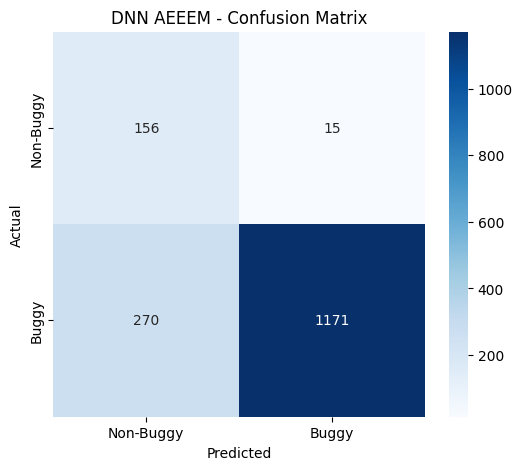

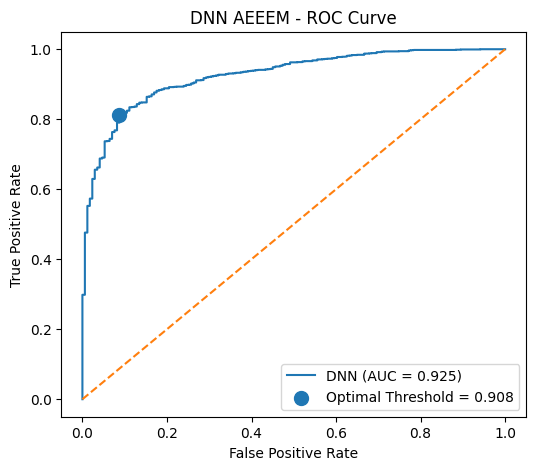


SAMPLE PREDICTIONS


,Actual,Probability,Predicted,Actual_Label,Predicted_Label
0,1,0.572700,0,Buggy,Non-Buggy
1,1,0.997569,1,Buggy,Buggy
2,1,0.995026,1,Buggy,Buggy
3,1,0.993467,1,Buggy,Buggy
4,1,0.990447,1,Buggy,Buggy
5,1,0.889793,0,Buggy,Non-Buggy
6,1,0.997489,1,Buggy,Buggy
7,1,0.964245,1,Buggy,Buggy
8,1,0.643563,0,Buggy,Non-Buggy
9,1,0.685265,0,Buggy,Non-Buggy



TESTING COMPLETED SUCCESSFULLY
Results saved to:
C:\Users\Cyber\Desktop\New folder\DNN_AEEEM_Test_Results.csv


In [18]:
# ============================================================
# AEEEM DNN MODEL - COMPLETE TESTING
# Uses EXACT preprocessing from original training notebook
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. PATHS
# ============================================================

data_path = r"C:\Users\Cyber\Desktop\New folder\dataset\AEEEM_combined.csv"

model_path = r"C:\Users\Cyber\Desktop\New folder\trained_DNN _model\DNN_AEEEM_Risk_Model.keras"

# ============================================================
# 2. CHECK FILES
# ============================================================

if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Dataset not found:\n{data_path}"
    )

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Model not found:\n{model_path}"
    )

print("=" * 70)
print("FILES FOUND")
print("=" * 70)

print("Dataset:", data_path)
print("Model  :", model_path)

# ============================================================
# 3. LOAD DATASET
# ============================================================

data = pd.read_csv(data_path)

print("\n" + "=" * 70)
print("ORIGINAL DATASET")
print("=" * 70)

print("Shape:", data.shape)

# ============================================================
# 4. CREATE TARGET
# EXACTLY LIKE YOUR ORIGINAL NOTEBOOK
# ============================================================

data['bug'] = (
    data['numberOfBugsFoundUntil:'] > 0
).astype(int)

# ============================================================
# 5. DROP EXACT COLUMNS USED DURING TRAINING
# ============================================================

drop_cols = [
    'class',
    'numberOfBugsFoundUntil:',
    'numberOfCriticalBugsFoundUntil:',
    'numberOfMajorBugsFoundUntil:',
    'numberOfHighPriorityBugsFoundUntil:',
    'numberOfNonTrivialBugsFoundUntil:'
]

data.drop(
    columns=drop_cols,
    inplace=True
)

print("\n" + "=" * 70)
print("AFTER PREPROCESSING")
print("=" * 70)

print("Dataset shape:", data.shape)

# ============================================================
# 6. SEPARATE X AND y
# ============================================================

X = data.drop(
    columns=['bug']
)

y = data['bug']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

# ============================================================
# 7. HANDLE MISSING VALUES
# EXACTLY LIKE TRAINING
# ============================================================

X = X.fillna(
    X.median()
)

print("\nMissing values after filling:")
print(X.isnull().sum().sum())

# ============================================================
# 8. SAME TRAIN/TEST SPLIT
# EXACTLY LIKE TRAINING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# ============================================================
# 9. STANDARD SCALING
# EXACTLY LIKE TRAINING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("\nScaled X_train:", X_train_scaled.shape)
print("Scaled X_test :", X_test_scaled.shape)

# ============================================================
# 10. LOAD TRAINED MODEL
# ============================================================

model = tf.keras.models.load_model(
    model_path
)

print("\n" + "=" * 70)
print("MODEL LOADED")
print("=" * 70)

print("Model input :", model.input_shape)
print("Model output:", model.output_shape)

# ============================================================
# 11. VERIFY 56 FEATURES
# ============================================================

expected_features = model.input_shape[-1]

actual_features = X_test_scaled.shape[1]

print("\nModel expects :", expected_features)
print("Test provides :", actual_features)

if expected_features != actual_features:
    raise ValueError(
        f"Feature mismatch! Model expects "
        f"{expected_features}, but test data has "
        f"{actual_features}."
    )

print("✓ Feature count matches!")

# ============================================================
# 12. MODEL EVALUATION
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("\n" + "=" * 70)
print("MODEL TEST RESULT")
print("=" * 70)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

print(
    f"Test Loss    : {test_loss:.4f}"
)

# ============================================================
# 13. PREDICT PROBABILITIES
# ============================================================

y_pred_probability = model.predict(
    X_test_scaled,
    verbose=0
).ravel()

print("\nFirst 10 prediction probabilities:")

for i, probability in enumerate(
    y_pred_probability[:10]
):
    print(
        f"Sample {i+1}: {probability:.6f}"
    )

# ============================================================
# 14. ROC-AUC + OPTIMAL THRESHOLD
# EXACTLY LIKE YOUR ORIGINAL NOTEBOOK
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_probability
)

auc_score = roc_auc_score(
    y_test,
    y_pred_probability
)

optimal_index = np.argmax(
    tpr - fpr
)

optimal_threshold = thresholds[
    optimal_index
]

# ============================================================
# 15. FINAL PREDICTIONS
# ============================================================

y_pred = (
    y_pred_probability >= optimal_threshold
).astype(int)

print("\n" + "=" * 70)
print("ROC RESULTS")
print("=" * 70)

print(
    f"ROC-AUC           : {auc_score:.4f}"
)

print(
    f"Optimal Threshold : {optimal_threshold:.4f}"
)

# ============================================================
# 16. CLASSIFICATION METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("\n" + "=" * 70)
print("CLASSIFICATION PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc_score:.4f}")

# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Non-Buggy",
            "Buggy"
        ],
        zero_division=0
    )
)

# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Non-Buggy',
        'Buggy'
    ],
    yticklabels=[
        'Non-Buggy',
        'Buggy']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DNN AEEEM - Confusion Matrix")
plt.show()

# ============================================================
# 19. ROC CURVE
# ============================================================

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f'DNN (AUC = {auc_score:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    '--'
)

plt.scatter(
    fpr[optimal_index],
    tpr[optimal_index],
    s=100,
    label=f'Optimal Threshold = {optimal_threshold:.3f}'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DNN AEEEM - ROC Curve")
plt.legend()
plt.show()

# ============================================================
# 20. PREDICTION RESULTS TABLE
# ============================================================

results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_pred_probability,
    "Predicted": y_pred
})

results["Actual_Label"] = results["Actual"].map({
    0: "Non-Buggy",
    1: "Buggy"
})

results["Predicted_Label"] = results["Predicted"].map({
    0: "Non-Buggy",
    1: "Buggy"
})

print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)

display(
    results.head(20)
)

# ============================================================
# 21. SAVE TEST RESULTS
# ============================================================

output_path = (
    r"C:\Users\Cyber\Desktop\New folder"
    r"\DNN_AEEEM_Test_Results.csv"
)

results.to_csv(
    output_path,
    index=False
)

print("\n" + "=" * 70)
print("TESTING COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    f"Results saved to:\n{output_path}")


In [19]:
import keras

model = keras.models.load_model(
    r"C:\Users\Cyber\Desktop\New folder\trained_DNN _model\DNN_AEEEM_Risk_Model.keras"
)

print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

for layer in model.layers:
    print(layer.name, layer.__class__.__name__, layer.input_shape if hasattr(layer, "input_shape") else "")

Input shape: (None, 56)
Output shape: (None, 1)
dense_10 Dense 
batch_normalization_8 BatchNormalization 
dropout_8 Dropout 
dense_11 Dense 
batch_normalization_9 BatchNormalization 
dropout_9 Dropout 
dense_12 Dense 
batch_normalization_10 BatchNormalization 
dropout_10 Dropout 
dense_13 Dense 
batch_normalization_11 BatchNormalization 
dropout_11 Dropout 
dense_14 Dense 


In [25]:
import os
import keras

model_path = r"C:\Users\Cyber\Desktop\New folder\trained_DNN _model\DNN_AEEEM_Risk_Model.keras"

fallback_model_path = r"C:\Users\Cyber\Desktop\New folder\risk_app\models\project_risk_model.joblib"

print("Model path:", model_path)
print("Model exists:", os.path.exists(model_path))

print("Fallback path:", fallback_model_path)
print("Fallback exists:", os.path.exists(fallback_model_path))

Model path: C:\Users\Cyber\Desktop\New folder\trained_DNN _model\DNN_AEEEM_Risk_Model.keras
Model exists: True
Fallback path: C:\Users\Cyber\Desktop\New folder\risk_app\models\project_risk_model.joblib
Fallback exists: True


In [26]:
import keras

model = keras.models.load_model(
    r"C:\Users\Cyber\Desktop\New folder\trained_DNN _model\DNN_AEEEM_Risk_Model.keras"
)

print("=" * 70)
print("MODEL INFORMATION")
print("=" * 70)

print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)

print("\nLAYERS")
print("-" * 70)

for i, layer in enumerate(model.layers):
    print(
        i,
        "|",
        layer.name,
        "|",
        layer.__class__.__name__
    )

MODEL INFORMATION
Input shape : (None, 56)
Output shape: (None, 1)

LAYERS
----------------------------------------------------------------------
0 | dense_10 | Dense
1 | batch_normalization_8 | BatchNormalization
2 | dropout_8 | Dropout
3 | dense_11 | Dense
4 | batch_normalization_9 | BatchNormalization
5 | dropout_9 | Dropout
6 | dense_12 | Dense
7 | batch_normalization_10 | BatchNormalization
8 | dropout_10 | Dropout
9 | dense_13 | Dense
10 | batch_normalization_11 | BatchNormalization
11 | dropout_11 | Dropout
12 | dense_14 | Dense


In [27]:
from pathlib import Path

root = Path(r"C:\Users\Cyber\Desktop\New folder")

keywords = [
    "DNN_AEEEM_Risk_Model",
    "StandardScaler",
    "56",
    "AEEEM",
]

for keyword in keywords:
    print("\n" + "=" * 80)
    print("SEARCHING:", keyword)
    print("=" * 80)

    for file in root.rglob("*"):
        if file.is_file() and file.suffix.lower() in [".py", ".ipynb", ".txt"]:
            try:
                text = file.read_text(encoding="utf-8", errors="ignore")
                if keyword.lower() in text.lower():
                    print(file)
            except Exception:
                pass


SEARCHING: DNN_AEEEM_Risk_Model
C:\Users\Cyber\Desktop\New folder\risk_app\ml_service.py

SEARCHING: StandardScaler
C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\sklearn\base.py
C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\sklearn\discriminant_analysis.py
C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\sklearn\pipeline.py
C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\sklearn\cluster\tests\test_hdbscan.py
C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py
C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\sklearn\compose\tests\test_column_transformer.py
C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\sklearn\compose\tests\test_target.py
C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\sklearn\decomposition\tests\test_kernel_pca.py
C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-packages\sklearn\ensemble\_stacking.py
C:\Users\Cyber\Desktop\New folder\.venv\Lib\site-pac